# Contamination-Aware Differential Gene Expression Analysis

## Background

Imaging-based spatial transcriptomics methods like Xenium In Situ enable single-molecule RNA measurement but face a critical challenge: **transcript spill-over** due to imperfect cell segmentation. Transcripts from neighboring cells can be incorrectly assigned to target cells, particularly in densely packed tissues.

**Problem:** When performing differential gene expression (DGE) analysis, we cannot distinguish whether detected genes are:
- Genuinely upregulated in target cells, or
- Artifacts from misassigned transcripts from neighbors

**Solution:** Compare cells not only against each other but also against their spatial neighborhoods to identify contamination artifacts.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
from insitupy import InSituData, CACHE
from insitupy.tools import dge
import pandas as pd

## Load Data

In [3]:
insitupy_project = Path(CACHE / "out/demo_insitupy_project")
xd = InSituData.read(insitupy_project)

xd.load_images()
xd.load_cells()
xd.load_annotations()

## Contamination-Aware DGE Workflow

The `dge()` function performs contamination-aware differential gene expression analysis in a single step. It:

1. Compares target vs reference cell types (standard DGE)
2. Assesses neighborhood contamination for both groups
3. Integrates results to identify potential artifacts

**Parameters:**
- `consider_neighbors=True`: Enables contamination analysis
- `exclude_ambiguous_assignments=True`: Filters genes with conflicting signals

In [4]:
# Run contamination-aware DGE analysis
dge_results = dge(
    target=xd,
    target_cell_type_tuple=("cell_type_dc_sub_final", "Breast cancer subtype 4"),
    ref_cell_type_tuple=("cell_type_dc_sub_final", "Breast cancer subtype 1"),
    ref=None,
    method="wilcoxon",
    consider_neighbors=True,
    exclude_ambiguous_assignments=True
)


Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 'wilcoxon'.
Building spatial graph (radius=20, weighted=False)...
Selected 6445 'Breast cancer subtype 4' cells as targets
Excluding same-celltype neighbors from adjacency matrix...
Computing mean neighbor expression...
Computing gex_diff = gex_target - gex_neighbor ...
Running paired tests (wilcoxon) per gene and computing effect sizes...


genes: 100%|██████████| 297/297 [00:02<00:00, 119.85it/s]


Applying multiple-testing correction...

ANALYSIS SUMMARY
Target cell type: 'Breast cancer subtype 4'
Target cells: 6445/156447 (4.1%)
Strategy: mean
Genes tested: 297
Target cells without neighbors: 1340 (20.8%)
Median neighbors per target cell: 3.0

Building spatial graph (radius=20, weighted=False)...
Selected 31016 'Breast cancer subtype 1' cells as targets
Excluding same-celltype neighbors from adjacency matrix...
Computing mean neighbor expression...
Computing gex_diff = gex_target - gex_neighbor ...
Running paired tests (wilcoxon) per gene and computing effect sizes...


genes: 100%|██████████| 297/297 [00:09<00:00, 30.11it/s]


Applying multiple-testing correction...

ANALYSIS SUMMARY
Target cell type: 'Breast cancer subtype 1'
Target cells: 31016/156447 (19.8%)
Strategy: mean
Genes tested: 297
Target cells without neighbors: 13137 (42.4%)
Median neighbors per target cell: 2.0



In [5]:
# Display results
print("\n=== DGE Results Summary ===")
print(f"Total genes: {len(dge_results.main)}")
print(f"Significant upregulated:")
print(f"\t- Target vs. reference: {((dge_results.main['padj'] < 0.05) & (dge_results.main['log2foldchange'] > 0)).sum()}")
print(f"\t- Target vs. neighborhood: {((dge_results.target_neighborhood['padj'] < 0.05) & (dge_results.target_neighborhood['log2foldchange'] > 0)).sum()}")
print(f"\t- Reference vs. neighborhood: {((dge_results.ref_neighborhood['padj'] < 0.05) & (dge_results.ref_neighborhood['log2foldchange'] > 0)).sum()}")


=== DGE Results Summary ===
Total genes: 297
Significant upregulated:
	- Target vs. reference: 57
	- Target vs. neighborhood: 79
	- Reference vs. neighborhood: 85


## Understanding the Results

The `dge()` function returns a `DiffExprResults` object containing:

**Main attributes:**
- `main`: Standard DGE results (target vs reference)
- `target_neighborhood`: Target cells vs their spatial neighborhood
- `ref_neighborhood`: Reference cells vs their spatial neighborhood
- `config`: Analysis configuration and metadata

**Key columns in results DataFrames:**

| Column | Description |
|--------|-------------|
| `log2foldchange` | Log2 fold change between conditions |
| `padj` | FDR-adjusted p-value |

**Accessing results:**

In [6]:
# Main DGE results
main_results = dge_results.main

# Neighborhood comparisons (if consider_neighbors=True)
if dge_results.has_neighbors():
    target_nb = dge_results.target_neighborhood  # Target vs neighbors
    ref_nb = dge_results.ref_neighborhood        # Reference vs neighbors

# Get all results as dictionary
all_results = dge_results.get_all_results()


In [7]:
print(all_results)

{'main':           log2foldchange           padj      scores  neg_log10_pvals
gene                                                                
SERPINA3        5.463246  1.000000e-300  101.212189            300.0
CEACAM6         3.637490  1.000000e-300   94.099846            300.0
AGR3            4.773612  1.000000e-300   84.277008            300.0
TACSTD2         1.096257  1.000000e-300   64.926903            300.0
ESR1            2.567329  1.000000e-300   50.270954            300.0
...                  ...            ...         ...              ...
TCIM           -1.277700  1.000000e-300  -49.620869            300.0
MDM2           -0.940504  1.000000e-300  -50.664825            300.0
FASN           -0.892925  1.000000e-300  -60.591518            300.0
KRT7           -0.575407  1.000000e-300  -61.039478            300.0
ABCC11         -1.645688  1.000000e-300  -62.645016            300.0

[297 rows x 4 columns], 'target_neighborhood':         n_target_cells  n_cells_used  n_cells_

**Interpretation patterns:**

When neighborhood analysis is enabled (`consider_neighbors=True`):

| Target vs Reference (`.main`) | Target vs Neighbors (`.target_neighborhood`) | Reference vs Neighbors (`.ref_neighborhood`) | Interpretation |
|----------|---------------------|------------------------|----------------|
| Upregulated (sig.) | Upregulated or NS | Any | **Genuine upregulation** |
| Upregulated (sig.) | Downregulated (sig.) | Any | **Possible contamination in target cells** |
| Downregulated (sig.) | Any | Downregulated (sig.) | **Possible contamination in reference cells** |
| Downregulated (sig.) | Any | Upregulated or NS | **Genuine downregulation** |

**Saving and loading results:**

In [8]:
from insitupy.dataclasses.results import DiffExprResults

# Save complete analysis
dge_results.save("out/dge_results", overwrite=True)

# Load saved results
dge_results_reloaded = DiffExprResults.read("out/dge_results")

# Quick summary
print(dge_results_reloaded.summary())

Main DGE results: 297 genes
Neighbor comparison (A): 297 genes
Neighbor comparison (B): 297 genes
Configuration:
<bound method DiffExprConfigCollector.__repr__ of DiffExprConfigCollector(
  General:
    type: single-cell
    method_params: {'groupby': 'DGE_COMPARISON_COLUMN', 'reference': 'REFERENCE', 'method': 'wilcoxon', 'use_raw': False, 'corr_method': 'benjamini-hochberg'}
    cells_layer: None
    exclude_ambiguous_assignments: True
  Target:
    annotation: None
    cell_type: Breast cancer subtype 4
    region: None
    cell_number: 6445
    name: None
    metadata: None
  Reference:
    annotation: None
    cell_type: Breast cancer subtype 1
    region: None
    cell_number: 31016
    name: None
    metadata: None
)>


## Visualization

### Volcano Plot

Standard visualization showing significance vs fold change.

In [9]:
from insitupy.plotting import dual_foldchange_plot, volcano

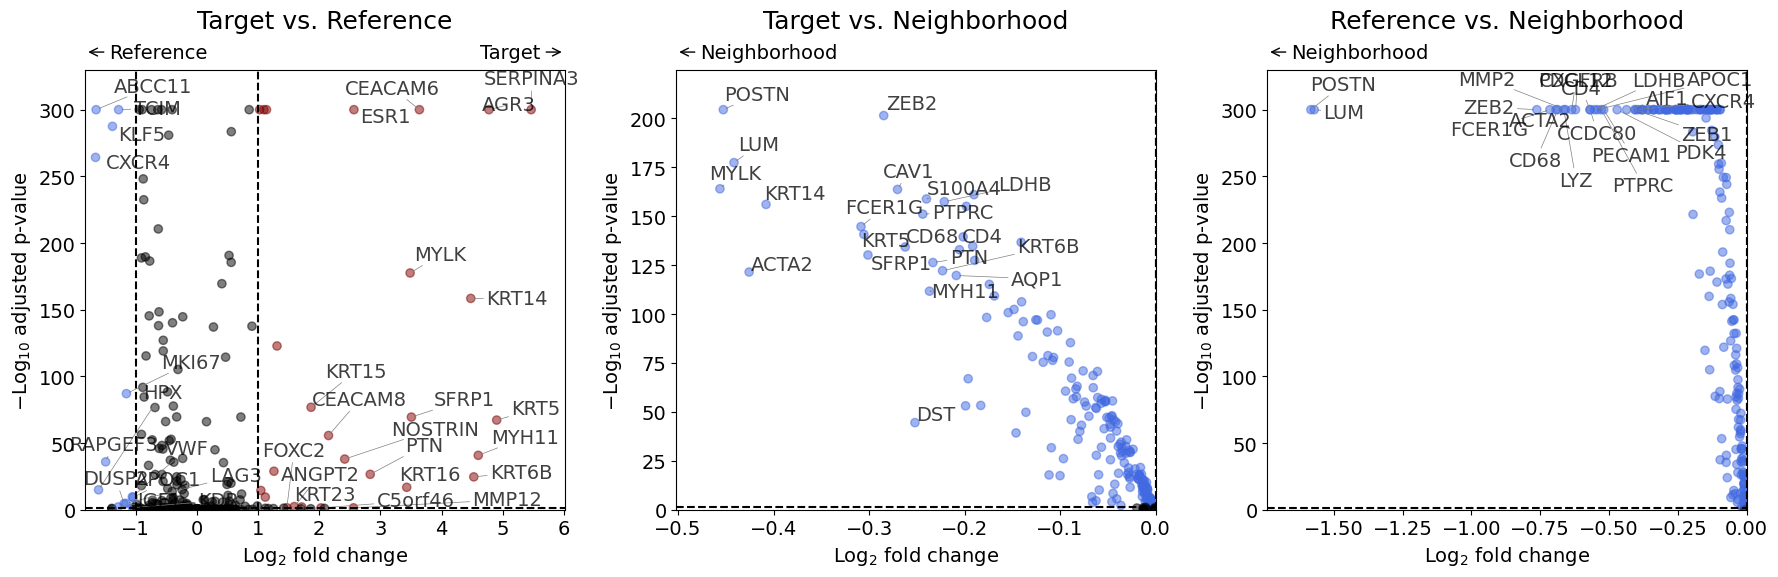

In [10]:
volcano(dge_results)

### Dual Fold Change Plot - Key visualization for contamination-aware differential gene expression analysis

Plots standard DGE (x-axis) against neighborhood contamination (y-axis) for both target and reference populations:

**Target panel (left):**
- **Upper half:** Target cells express more than their neighbors → genuine expression
- **Lower half:** Target cells express less than their neighbors → potential contamination from neighbors

**Reference panel (right):**
- **Upper half:** Reference cells express more than their neighbors → genuine expression
- **Lower half:** Reference cells express less than their neighbors → potential contamination from neighbors

**Interpretation:**
- Genes in **upper-right of target panel + positive main DGE**: Genuine upregulation in target
- Genes in **lower-right of target panel + positive main DGE**: Likely contamination artifact in target
- Genes in **upper-right of reference panel + negative main DGE**: Genuine upregulation in reference (= downregulation in target)

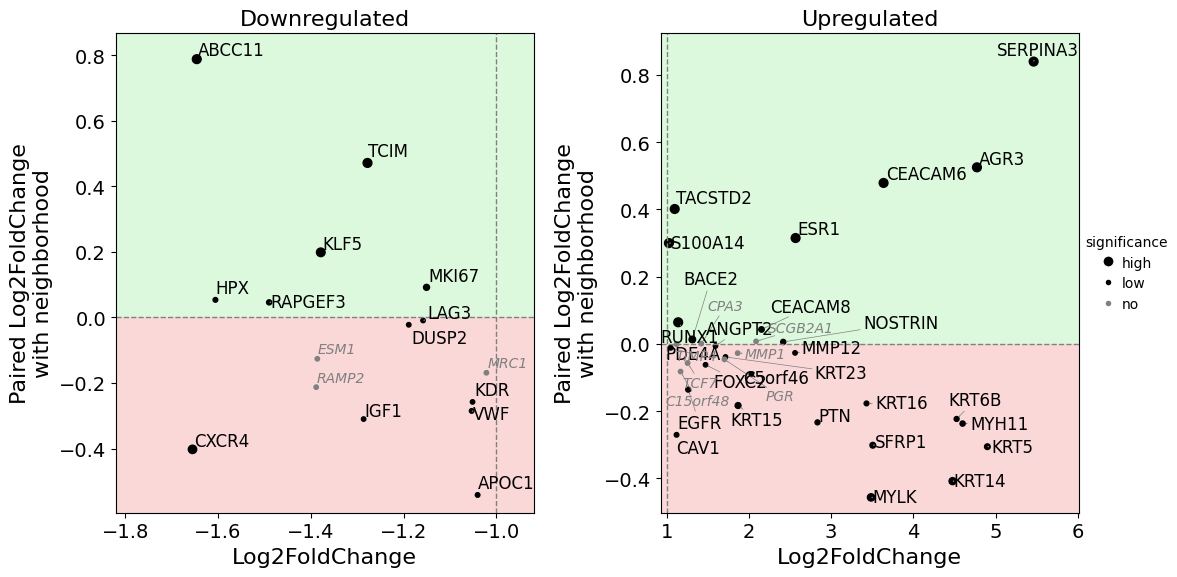

In [11]:
dual_foldchange_plot(
    dge_results,
    foldchange_threshold=2,
    adjust_labels=True,
    size_by_pvalue=True,
    show_nonsignificant=True
)

Using `show_config` one can also display more information on the cells used for the differential gene expression analysis. The `savepath` argument can be used to save the plot.

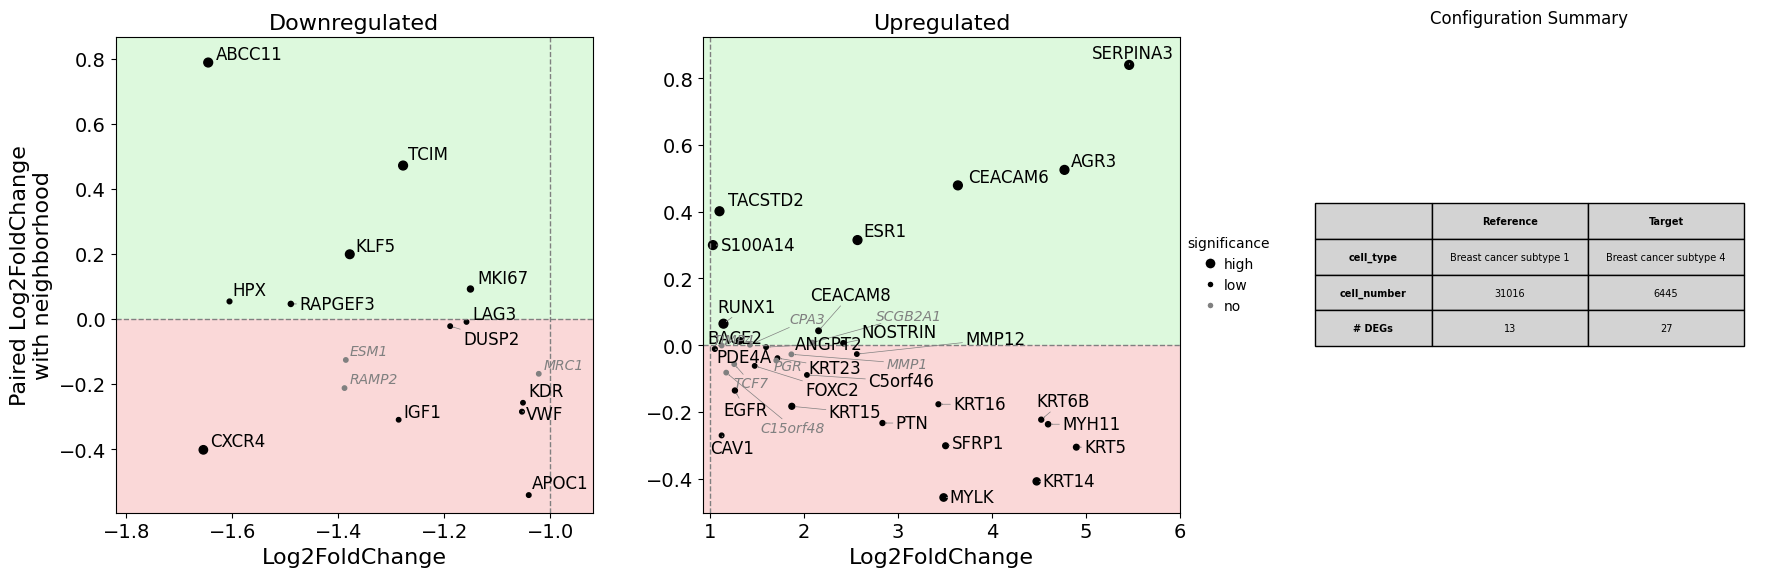

In [21]:
dual_foldchange_plot(
    dge_results,
    foldchange_threshold=2,
    adjust_labels=True,
    size_by_pvalue=True,
    show_nonsignificant=True,
    show_config=True,
    savepath="figures/dual_foldchange_config.pdf"
)